In [1]:
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import metpy
import project
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os

from wrf import getvar, interplevel
from wrf import getvar, interplevel
import metpy.calc as mpcalc
from metpy.interpolate import cross_section

In [2]:
file_path = 'wrf_data\index_1\wrfout_d01_2025-07-25_20_00_00.nc'
ncfile = Dataset(file_path)
wrf_ds = xr.open_dataset(file_path)
crs = project.get_projection(wrf_ds)

In [3]:
filename = file_path.split('\\')[-1].split('/')[-1]
parts = filename.split('_')
month_day = parts[2][5:] 
hour = parts[3]           
result = f"{month_day}_{hour}"

In [4]:
# --- 1. 提取所有必要的 3D 诊断变量 ---
pres = getvar(ncfile, "pressure")      # 全层气压 (hPa)
z = getvar(ncfile, "z", units="dm")    # 全层位势高度 (dm)
tc = getvar(ncfile, "tc")              # 全层摄氏温度 (C)
ua = getvar(ncfile, "ua")              # 全层 U 风分量
va = getvar(ncfile, "va")              # 全层 V 风分量

wa = getvar(ncfile, "wa") 
theta = getvar(ncfile, "theta")
q = getvar(ncfile, "QVAPOR")    # 混合比
rh = getvar(ncfile, "rh")  
z_500 = interplevel(z, pres, 500)  # 500 hPa 位势高度

In [5]:
lon_2d_orgin = z_500['XLONG']
lat_2d_orgin = z_500['XLAT']

sigma = 2.0
z_500_smooth = gaussian_filter(z_500.values, sigma=sigma)

In [6]:
start = (37.5,110)
end = (45,125)

In [7]:
# 1. 把变量塞进 Dataset
ds_to_slice = xr.Dataset({
    "pres": pres,
    "temp_c": tc,
    "ua": ua,
    "va": va,
    'wa': wa,
    'theta': theta,
    'q': q,
    'th': rh,
    'height': z
})

# --- 新加这一行，删掉多余的时间坐标 ---
if 'XTIME' in ds_to_slice.coords:
    ds_to_slice = ds_to_slice.drop_vars('XTIME')
    
# 2. 统一经纬度坐标名称（把 XLAT 改名为 lat，方便后续使用）
ds_to_slice = ds_to_slice.rename({'XLAT': 'lat', 'XLONG': 'lon'})

# 3. 计算真正的距离坐标 (x, y)，单位必须是米 (meter)
# MetPy 剖面必须依赖这种线性距离坐标
dx = wrf_ds.attrs['DX']
dy = wrf_ds.attrs['DY']
nx = ds_to_slice.dims['west_east']
ny = ds_to_slice.dims['south_north']

ds_to_slice = ds_to_slice.assign_coords(
    x=('west_east', np.arange(0, nx * dx, dx)),
    y=('south_north', np.arange(0, ny * dy, dy))
)
ds_to_slice = ds_to_slice.rename({'south_north': 'y', 'west_east': 'x'})

# 4. 给 x 和 y 加上 MetPy 必须的单位属性
ds_to_slice.x.attrs['units'] = 'meter'
ds_to_slice.y.attrs['units'] = 'meter'
ds_to_slice.x.attrs['standard_name'] = 'projection_x_coordinate'
ds_to_slice.y.attrs['standard_name'] = 'projection_y_coordinate'

In [8]:
# 绑定投影信息
ds_to_slice = ds_to_slice.metpy.assign_crs(crs.to_cf())

# 运行 parse_cf
ds_to_slice = ds_to_slice.metpy.parse_cf()

In [9]:
start = (37.5, 110) # 维度, 经度
end = (45, 125)

# 执行剖面计算
# 此时 cross 里会包含 pres, temp_c, ua, va 等所有变量
cross = cross_section(ds_to_slice, start, end).set_coords(('lat', 'lon'))

d:\Anaconda\envs\wrf_analysis\lib\site-packages\xarray\core\missing.py:559: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
d:\Anaconda\envs\wrf_analysis\lib\site-packages\xarray\core\missing.py:560: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imax = index.get_loc(maxval, method="nearest")
d:\Anaconda\envs\wrf_analysis\lib\site-packages\xarray\core\missing.py:559: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
d:\Anaconda\envs\wrf_analysis\lib\site-packages\xarray\core\missing.py:560: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise i

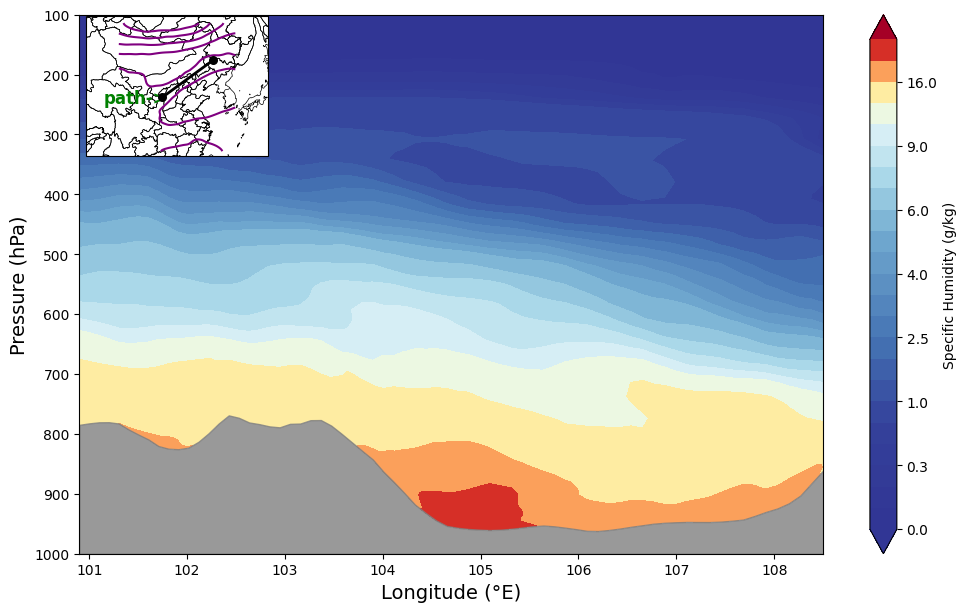

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 提取数据并转为 numpy
lons = cross['lon'].values
pres = cross['pres'].values
temp = cross['temp_c'].values
q = cross['q'].values
height = cross['height'].values

# 2. 广播经度
lon_2d = np.broadcast_to(lons, pres.shape)

# 3. 绘图
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(1, 1, 1)

# 使用 np.nanmin/max 动态确定色阶，防止 NaN 干扰
t_min, t_max = np.nanmin(temp), np.nanmax(temp)
q_min, q_max = np.nanmin(q), np.nanmax(q)

# 使用对数风格的色阶，能看清高空的细微变化
levels = [0,0.1,0.2,0.3,0.4,0.5,1,1.5,2,2.5,3,3.5,4,4.5,5,6,7,8,9,10,12,16,20,25]
cf = ax.contourf(lon_2d, pres, q*1000, levels=levels, cmap='RdYlBu_r', extend='both')
cb = plt.colorbar(cf, ax=ax, label='Specific Humidity (g/kg)')

ter_pres = pres[0, :]                # 地面气压
ax.fill_between(lons, ter_pres, 1000, color='gray', alpha=0.8) # 从地面气压填到1000hPa

# --- 关键：使用 nanmin/nanmax 避开那些讨厌的 NaN ---
x_min, x_max = np.nanmin(lons), np.nanmax(lons)
ax.set_xlim(x_min, x_max)

# 气压轴：通常从地面到高空
ax.set_ylim(1000,100)  # 15 km 的高度范围

ax.set_xlabel("Longitude (°E)",fontsize=14)
ax.set_ylabel("Pressure (hPa)",fontsize=14)

ax_inset = fig.add_axes([0.1064, 0.6787, 0.2, 0.2], projection=crs)
project.plot_background(lon_2d_orgin.min(), lon_2d_orgin.max(), lat_2d_orgin.min(), lat_2d_orgin.max(), ax_inset)
ax_inset.contour(lon_2d_orgin, lat_2d_orgin, z_500_smooth,levels=np.arange(520,600,4),colors='purple',transform=ccrs.PlateCarree())

# 在剖面图上标出剖面线
# 直接用你定义的起点终点画，绝对不会反！
start_lat, start_lon = 37.5, 110
end_lat, end_lon = 45, 125

# 画剖面线
ax_inset.plot([start_lon, end_lon], [start_lat, end_lat],
              color='black', linewidth=2, transform=ccrs.PlateCarree(), zorder=5)

# 画起点终点
ax_inset.scatter([start_lon, end_lon], [start_lat, end_lat],
                 color='black', s=30, transform=ccrs.PlateCarree(), zorder=6)

ax_inset.text(start_lon-15, start_lat-3, 'path->', transform=ccrs.PlateCarree(),fontsize=12,color='green',fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.4)
plt.show()